# **Requirement 4: Slightly Non-Stationary Environments with Multiple Campaigns**

We expand the bidding architecture to a Combinatorial Multi-Armed Bandit problem with a global budget operating in a **piecewise-stationary (slightly non-stationary) environment**.

At each round $t$, the advertiser faces the identical combinatorial constraints (conflict graph) and budget limit $B$ established in previous requirements, but the underlying market dynamics are no longer static:
1. The total time horizon $T$ is partitioned into distinct, unknown intervals.
2. Within each specific interval, the vector of highest competing bids $\mathbf{m}_t$ is drawn from a fixed joint distribution. The distributions are different in each interval.
3. The advertiser still selects a combinatorial bid vector $\mathbf{b}_t$, wins auctions where $b_{i,t} \geq m_{i,t}$, and incurs costs/utilities identically, but must now actively track the evolving market to avoid optimizing for obsolete historical distributions.

The algorithm must dynamically adapt to these unannounced breakpoints while optimizing the combinatorial super-arm selection. We need to extend the Combinatorial-UCB approach from Requirement 2 using two distinct tracking mechanics:
* **Combinatorial-UCB with Sliding Window:** A passive adaptation policy that actively forgets older observations, calculating empirical means and confidence bounds using only a recent rolling window of history.
* **Combinatorial-UCB with a Change Detector:** An active adaptation policy that monitors the sequence of feedback for statistical drift and triggers a hard reset of its internal memory state when a distribution shift is detected.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, norm

# Ensure project root is in path for imports
sys.path.append(os.path.abspath(os.path.join('..')))
from src.environments import BaseEnvironment
from src.multi_campign_environments import MultiCampaignEnvironment

In [2]:
import numpy as np
from scipy.stats import norm, beta as beta_dist

class SlightlyNonStationaryMultiCampaignEnvironment:
    """
    Req 4: Slightly non-stationary environment with arbitrary interval lengths.

    breakpoints      : list of round indices where a new interval starts.
                       Must include 0. e.g. [0, 200, 400] with T=600.
    dist_type        : 'gaussian', 'beta', or 'uniform'
    interval_configs : list of dicts, one per interval.
                       gaussian -> {"means": (N,), "stds":  (N,)}
                       beta     -> {"alphas": (N,), "betas": (N,)}
                       uniform  -> {"lows":  (N,), "highs": (N,)}
                       If None, random configs are generated.
    seed             : controls both config generation and pre-sampling.
    """
    def __init__(self, values, B, T, conflict_matrix,
                 breakpoints, dist_type='gaussian',
                 interval_configs=None, seed=None):

        self.values          = np.array(values, dtype=float)
        self.N               = len(self.values)
        self.conflict_matrix = np.array(conflict_matrix, dtype=bool)
        self.T               = int(T)
        self.B               = float(B)
        self.dist_type       = dist_type
        self.t               = 0
        self.spent           = 0.0
        self.bankrupt        = False

        # ── Validate breakpoints ──────────────────────────────────────────────
        breakpoints = list(breakpoints)
        assert breakpoints[0] == 0,                        "First breakpoint must be 0."
        assert breakpoints == sorted(breakpoints),         "Breakpoints must be sorted."
        assert all(0 <= bp < T for bp in breakpoints),    "Breakpoints must be in [0, T)."

        self.breakpoints = breakpoints
        self.starts      = np.array(breakpoints, dtype=int)
        self.ends        = np.append(self.starts[1:], self.T)
        self.durations   = self.ends - self.starts
        self.n_intervals = len(breakpoints)

        # ── Build or validate interval configs ────────────────────────────────
        # interval_configs is PUBLIC so the outer script and clairvoyant
        # can access true distribution parameters via env.interval_configs
        rng = np.random.default_rng(seed)
        if interval_configs is None:
            self.interval_configs = self._random_configs(rng)
        else:
            assert len(interval_configs) == self.n_intervals, \
                f"Expected {self.n_intervals} configs, got {len(interval_configs)}"
            self.interval_configs = interval_configs

        # ── Pre-sample (T, N) competing bid matrix ────────────────────────────
        self.m_sequence = np.zeros((self.T, self.N))
        for k, cfg in enumerate(self.interval_configs):
            s, e = int(self.starts[k]), int(self.ends[k])
            dur  = e - s
            self.m_sequence[s:e] = self._sample(cfg, dur, rng)  # (dur, N)

        # ── Map each round to its interval index ──────────────────────────────
        self.round_to_interval = np.zeros(self.T, dtype=int)
        for k in range(self.n_intervals):
            self.round_to_interval[self.starts[k]:self.ends[k]] = k

    # ── Sampling ──────────────────────────────────────────────────────────────

    def _sample(self, cfg, size, rng):
        """Draw (size, N) competing bids from this interval's distribution."""
        out = np.zeros((size, self.N))
        for i in range(self.N):
            if self.dist_type == 'gaussian':
                out[:, i] = np.clip(
                    rng.normal(cfg["means"][i], cfg["stds"][i], size=size),
                    0.0, None)
            elif self.dist_type == 'beta':
                out[:, i] = rng.beta(cfg["alphas"][i], cfg["betas"][i], size=size)
            elif self.dist_type == 'uniform':
                out[:, i] = rng.uniform(cfg["lows"][i], cfg["highs"][i], size=size)
            else:
                raise ValueError(f"Unknown dist_type '{self.dist_type}'.")
        return out

    # ── Random config generation ──────────────────────────────────────────────

    def _random_configs(self, rng):
        configs = []
        for _ in range(self.n_intervals):
            if self.dist_type == 'gaussian':
                configs.append({
                    "means": rng.uniform(0.2, 0.8, size=self.N),
                    "stds":  rng.uniform(0.1, 0.3, size=self.N),
                })
            elif self.dist_type == 'beta':
                configs.append({
                    "alphas": rng.uniform(1.0, 5.0, size=self.N),
                    "betas":  rng.uniform(1.0, 5.0, size=self.N),
                })
            elif self.dist_type == 'uniform':
                lows  = rng.uniform(0.0, 0.4, size=self.N)
                highs = lows + rng.uniform(0.3, 0.6, size=self.N)
                configs.append({"lows": lows, "highs": highs})
        return configs

    # ── CDF — used by clairvoyant and for expected_net computation ────────────

    def win_prob(self, interval_idx, i, b):
        """
        P(m_i <= b) under interval interval_idx, campaign i.
        Public so the clairvoyant can call env.win_prob(k, i, b) directly.
        """
        cfg = self.interval_configs[interval_idx]
        if self.dist_type == 'gaussian':
            return norm.cdf(b, loc=cfg["means"][i], scale=cfg["stds"][i])
        elif self.dist_type == 'beta':
            return beta_dist.cdf(b, cfg["alphas"][i], cfg["betas"][i])
        elif self.dist_type == 'uniform':
            lo, hi = cfg["lows"][i], cfg["highs"][i]
            return np.clip((b - lo) / (hi - lo), 0.0, 1.0)
    # ── Auction resolution ────────────────────────────────────────────────────

    def resolve_auction(self, bid_vector):
        if self.t >= self.T:
            raise RuntimeError("Horizon T exceeded.")

        bid_vector   = np.array(bid_vector, dtype=float)
        interval_idx = int(self.round_to_interval[self.t])

        # Draw competing bid FIRST — always available regardless of budget.
        # Fix for point 2: m_t is always returned, even on bankruptcy.
        m_t = self.m_sequence[self.t]

        if self.bankrupt:
            self.t += 1
            return (np.zeros(self.N, dtype=bool),
                    np.zeros(self.N), np.zeros(self.N),
                    {"expected_net": 0.0, "m_t": m_t,
                     "interval": interval_idx})

        # Conflict check
        active = np.where(bid_vector > 0.0)[0]
        for a in range(len(active)):
            for b in range(a + 1, len(active)):
                if self.conflict_matrix[active[a], active[b]]:
                    raise ValueError(
                        f"Conflict: campaigns {active[a]} and {active[b]}")

        # Expected net utility under current interval's true distribution
        win_probs    = np.array([self.win_prob(interval_idx, i, bid_vector[i])
                                 for i in range(self.N)])
        expected_net = float(np.sum((self.values - bid_vector) * win_probs))

        # Resolve auction
        won_vector    = bid_vector >= m_t
        proposed_cost = float(np.sum(np.where(won_vector, bid_vector, 0.0)))

        if self.spent + proposed_cost > self.B:
            self.bankrupt = True
            self.t += 1
            return (np.zeros(self.N, dtype=bool),
                    np.zeros(self.N), np.zeros(self.N),
                    {"expected_net": 0.0, "m_t": m_t,
                     "interval": interval_idx})

        costs   = np.where(won_vector, bid_vector,               0.0)
        rewards = np.where(won_vector, self.values - bid_vector, 0.0)
        self.spent += proposed_cost
        self.t     += 1

        return (won_vector, rewards, costs,
                {"expected_net": expected_net, "m_t": m_t,
                 "interval": interval_idx})

Code for the computation of the clairvoyant that returns gamma (M,) — optimal distrib over super-arms, 
super_arms (M, N) — bid index per campaign per super-arm and 
net_per_round : expected net utility per round with optimal distrib



In [3]:
def compute_clairvoyant(values, bid_space, B, T, conflict_matrix, cdf_functions):
    values = np.array(values, dtype=float)
    bid_space = np.array(bid_space, dtype=float)
    N, K = len(values), len(bid_space)
    rho = float(B) / float(T)

    # Injecting the distinct CDFs
    win_prob = np.zeros((N, K))
    for i in range(N):
        win_prob[i, :] = cdf_functions[i](bid_space)
    
    win_prob = np.clip(win_prob, 0.0, 1.0)

    # Net Expectations
    mu_f = (values[:, None] - bid_space[None, :]) * win_prob
    mu_c = bid_space[None, :] * win_prob

    # Pinning Inactivity
    mu_f[:, 0] = 0.0
    mu_c[:, 0] = 0.0

    valid_per_campaign = [[k for k, b in enumerate(bid_space) if b <= values[i]] for i in range(N)]
    valid_arms = []
    for combo in itertools.product(*valid_per_campaign):
        conflict = False
        for i in range(N):
            for j in range(i + 1, N):
                if conflict_matrix[i][j] and combo[i] != 0 and combo[j] != 0:
                    conflict = True
                    break
            if conflict: break
        if not conflict: valid_arms.append(combo)

    super_arms = np.array(valid_arms, dtype=int)
    M = len(super_arms)

    idx = np.arange(N)[None, :]
    U_sa = np.sum(mu_f[idx, super_arms], axis=1)
    C_sa = np.sum(mu_c[idx, super_arms], axis=1)

    res = optimize.linprog(
        -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=np.array([rho]),
        A_eq=np.ones((1, M)), b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * M, method='highs-ds'
    )
    
    if not res.success:
        raise ValueError(f"Fluid LP failed: {res.message}")
        
    gamma = np.clip(res.x, 0.0, 1.0)
    gamma /= gamma.sum()
    net_per_round = float(np.dot(gamma, U_sa))
    
    return gamma, super_arms, net_per_round


Some plots to see the characteristics of the environment. You can vary the parameters : CONFLICT matrix, B budget, T rounds , BID_SPACE, values, BREAKPOINTS , the means and stds of distrib of each arm per interval ... 

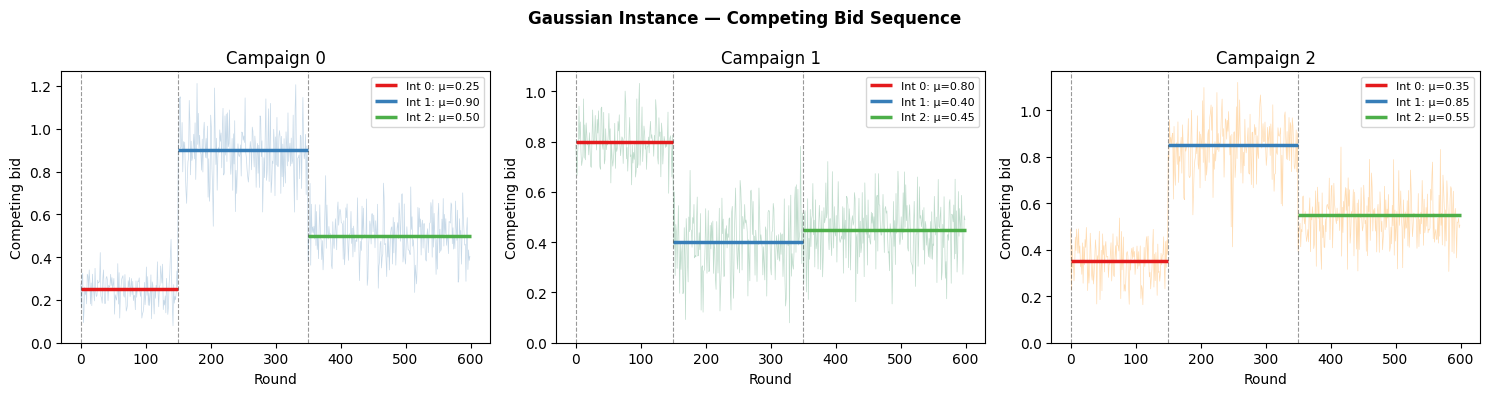

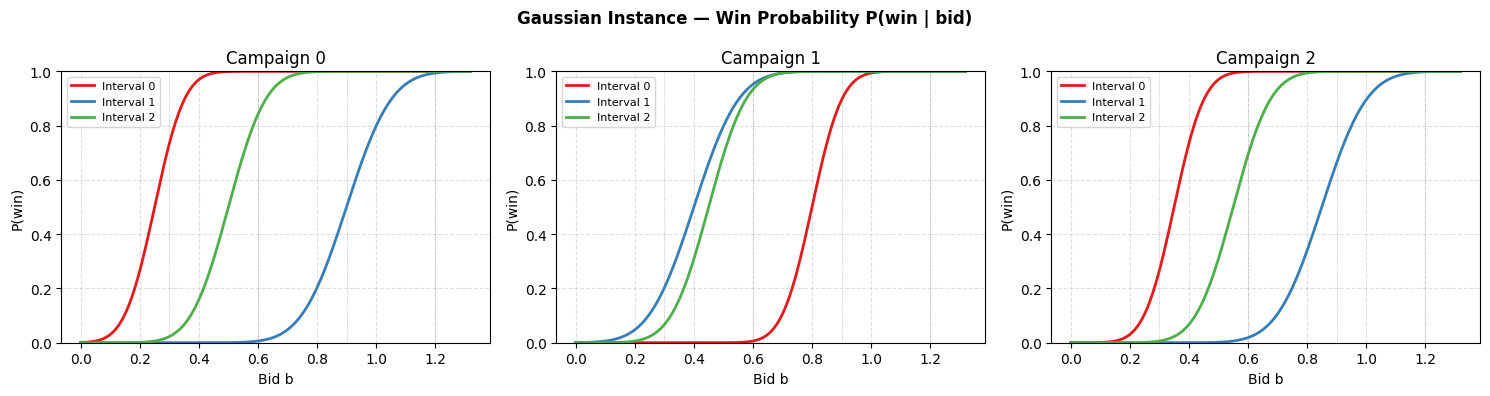

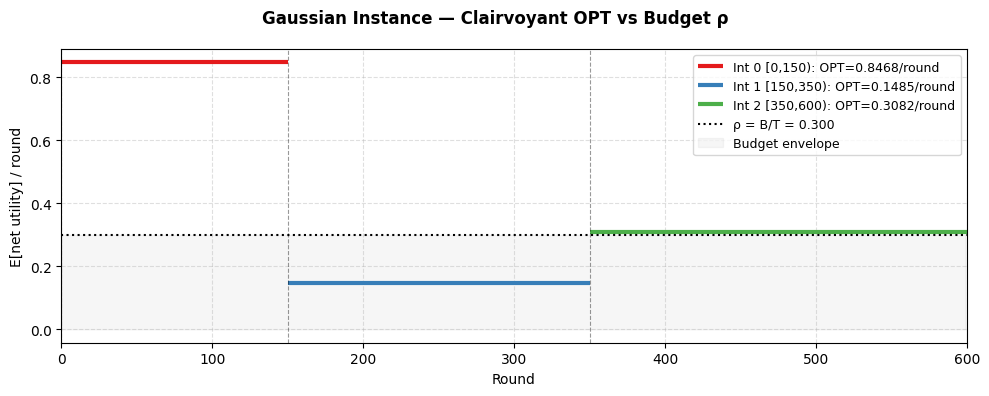

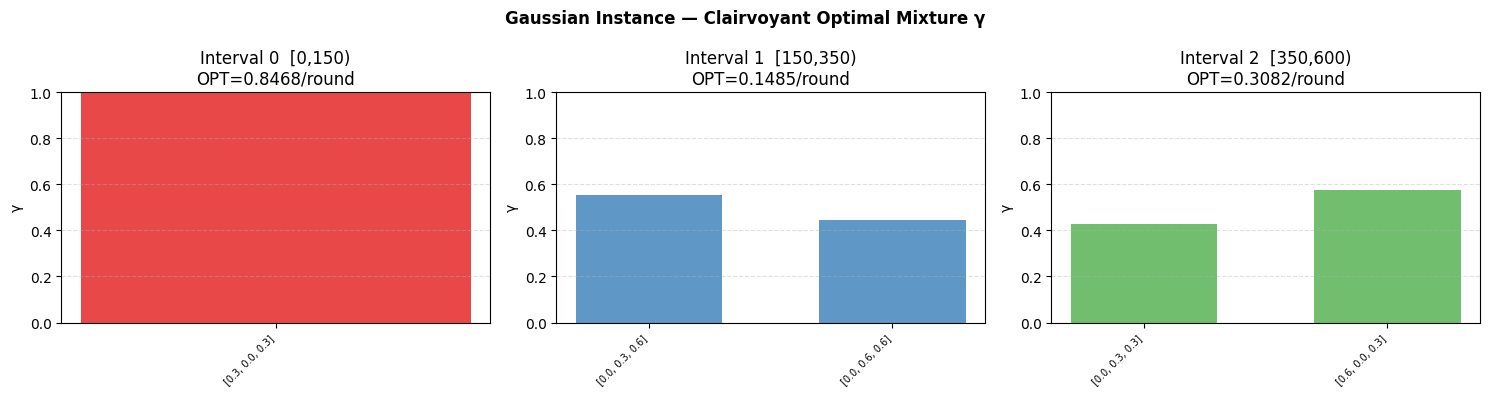

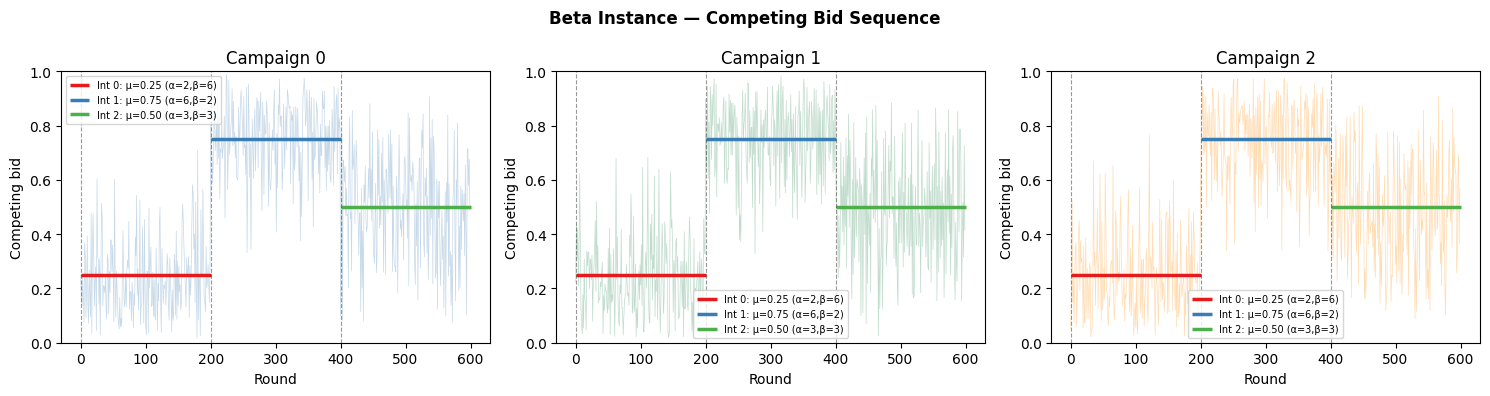

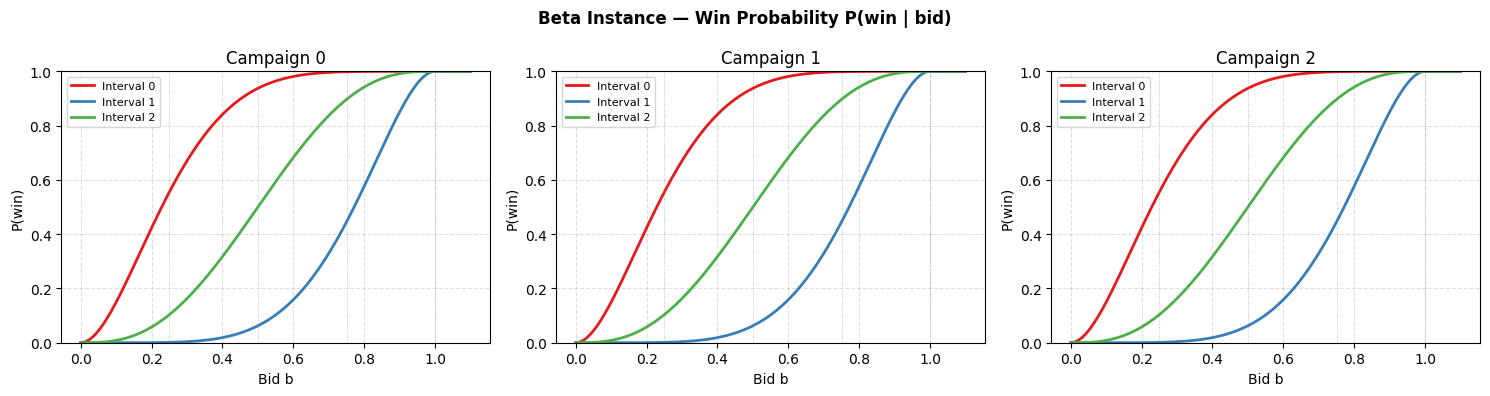

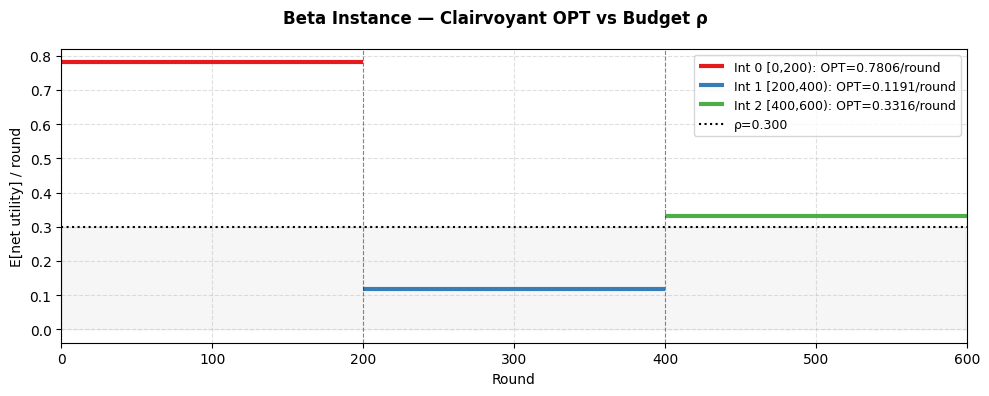

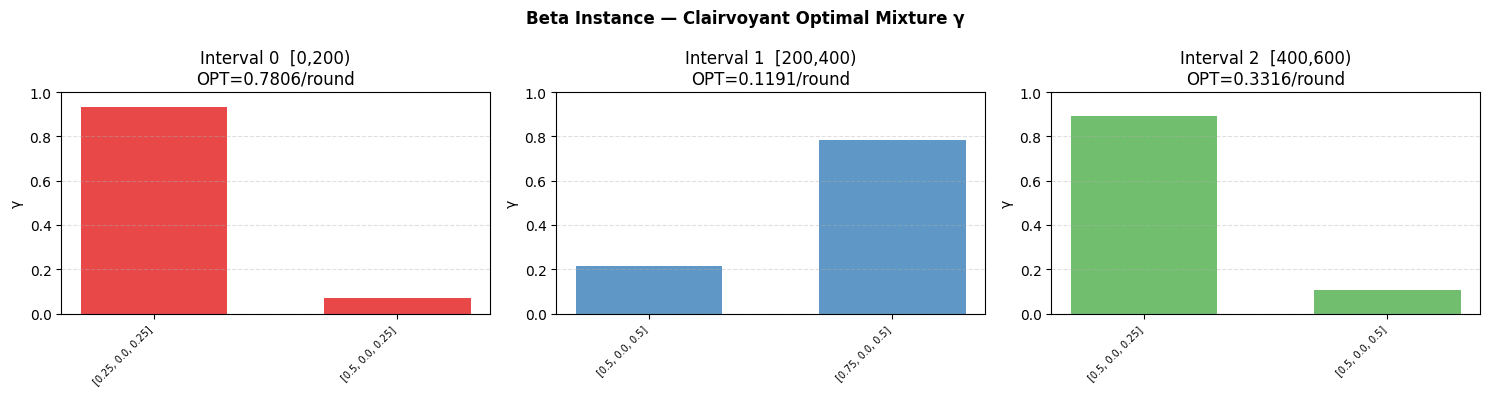

In [4]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy.stats import norm, beta
from scipy import optimize

# ── Settings ──────────────────────────────────────────────────────────────────

VALUES      = [1.2, 0.8, 1.0]
BID_SPACE   = np.array([0.0, 0.3, 0.6, 0.9, 1.2])
T           = 600
B           = 0.3 * T
CONFLICT    = [[False, True,  False],
               [True,  False, False],
               [False, False, False]]
N           = 3
INT_COLORS  = ['#e41a1c', '#377eb8', '#4daf4a']
CAM_COLORS  = ['steelblue', 'seagreen', 'darkorange']

# ══════════════════════════════════════════════════════════════════════════════
# INSTANCE 1: GAUSSIAN — slow drift, means shift gradually across intervals
# Interesting because: budget is tight in interval 1 (high competition),
# agent must adapt bidding strategy.
# ══════════════════════════════════════════════════════════════════════════════

BREAKPOINTS_G = [0, 150, 350] 
# 3 intervals: [0,150), [150,350), [350,600)
gaussian_configs = [
    {"means": np.array([0.25, 0.8, 0.35]), "stds": np.array([0.08, 0.08, 0.08])}, 
    {"means": np.array([0.90, 0.4, 0.85]), "stds": np.array([0.12, 0.12, 0.12])},  
    {"means": np.array([0.50, 0.45, 0.55]), "stds": np.array([0.10, 0.10, 0.10])},  
]

env_g = SlightlyNonStationaryMultiCampaignEnvironment(
    values=VALUES, B=B, T=T, conflict_matrix=CONFLICT,
    breakpoints=BREAKPOINTS_G, dist_type='gaussian',
    interval_configs=gaussian_configs, seed=42)

# Clairvoyant per interval
cdfs_g = [
    [lambda b, m=gaussian_configs[k]["means"][i], s=gaussian_configs[k]["stds"][i]:
     norm.cdf(b, loc=m, scale=s) for i in range(N)]
    for k in range(env_g.n_intervals)
]
opt_g = [compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_g[k])
         for k in range(env_g.n_intervals)]
# opt_g[k] = (gamma, super_arms, net_per_round)

rho = B / T

# ── Plot 1a: Competing bid draws per campaign ─────────────────────────────────
rounds = np.arange(T)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Gaussian Instance — Competing Bid Sequence", fontweight='bold')
for i in range(N):
    axes[i].plot(rounds, env_g.m_sequence[:, i],
                 color=CAM_COLORS[i], alpha=0.3, lw=0.5)
    for k in range(env_g.n_intervals):
        s, e = int(env_g.starts[k]), int(env_g.ends[k])
        mu   = gaussian_configs[k]["means"][i]
        axes[i].hlines(mu, s, e,
                       colors=INT_COLORS[k], lw=2.5,
                       label=f"Int {k}: μ={mu:.2f}")
        axes[i].axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Competing bid")
    axes[i].set_ylim(bottom=0)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 1b: Win probability curves per campaign ──────────────────────────────
bid_grid = np.linspace(0.0, BID_SPACE.max() * 1.1, 300)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Gaussian Instance — Win Probability P(win | bid)", fontweight='bold')
for i in range(N):
    for k in range(env_g.n_intervals):
        wp = np.array([env_g.win_prob(k, i, b) for b in bid_grid])
        axes[i].plot(bid_grid, wp,
                     color=INT_COLORS[k], lw=2,
                     label=f"Interval {k}")
    for b in BID_SPACE[1:]:
        axes[i].axvline(b, color='grey', lw=0.6, linestyle=':', alpha=0.6)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Bid b")
    axes[i].set_ylabel("P(win)")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    axes[i].grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 1c: Clairvoyant OPT per round vs rho ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Gaussian Instance — Clairvoyant OPT vs Budget ρ", fontweight='bold')
for k in range(env_g.n_intervals):
    s, e              = int(env_g.starts[k]), int(env_g.ends[k])
    _, _, net_k       = opt_g[k]
    ax.hlines(net_k, s, e,
              colors=INT_COLORS[k], lw=3,
              label=f"Int {k} [{s},{e}): OPT={net_k:.4f}/round")
    ax.axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axhline(rho, color='black', lw=1.5, linestyle=':',
           label=f"ρ = B/T = {rho:.3f}")
ax.fill_between(rounds, 0, rho, color='grey', alpha=0.07, label='Budget envelope')
ax.set_xlabel("Round")
ax.set_ylabel("E[net utility] / round")
ax.set_xlim(0, T)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 1d: Clairvoyant mixture weights per interval ─────────────────────────
fig, axes = plt.subplots(1, env_g.n_intervals,
                         figsize=(5 * env_g.n_intervals, 4))
fig.suptitle("Gaussian Instance — Clairvoyant Optimal Mixture γ", fontweight='bold')
for k in range(env_g.n_intervals):
    gamma_k, super_arms_k, net_k = opt_g[k]
    active = np.where(gamma_k > 1e-4)[0]
    labels = [str(np.round(BID_SPACE[super_arms_k[m]], 2).tolist())
              for m in active]
    axes[k].bar(np.arange(len(active)), gamma_k[active],
                color=INT_COLORS[k], alpha=0.8, width=0.6)
    axes[k].set_xticks(np.arange(len(active)))
    axes[k].set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    axes[k].set_title(f"Interval {k}  [{env_g.starts[k]},{env_g.ends[k]})\n"
                      f"OPT={net_k:.4f}/round")
    axes[k].set_ylabel("γ")
    axes[k].set_ylim(0, 1)
    axes[k].grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# INSTANCE 2: BETA — shape changes across intervals, not just mean
# Interval 0: left-skewed (easy), Interval 1: right-skewed (hard),
# Interval 2: symmetric (medium). Interesting because the shape change
# affects win probability non-linearly — a bid that was good in Int 0
# may be useless in Int 1.
# ══════════════════════════════════════════════════════════════════════════════

BREAKPOINTS_B = [0, 200, 400]   # equal intervals this time
beta_configs = [
    {"alphas": np.array([2., 2., 2.]), "betas": np.array([6., 6., 6.])},  # easy
    {"alphas": np.array([6., 6., 6.]), "betas": np.array([2., 2., 2.])},  # hard
    {"alphas": np.array([3., 3., 3.]), "betas": np.array([3., 3., 3.])},  # medium
]

env_b = SlightlyNonStationaryMultiCampaignEnvironment(
    values=[1.0, 0.7, 0.9], B=B, T=T, conflict_matrix=CONFLICT,
    breakpoints=BREAKPOINTS_B, dist_type='beta',
    interval_configs=beta_configs, seed=7)

# Beta lives on [0,1] — use rescaled bid space
BID_SPACE_B = BID_SPACE / BID_SPACE.max()  # [0, 0.25, 0.5, 0.75, 1.0]
VALUES_B    = [1.0, 0.7, 0.9]

cdfs_b = [
    [lambda b, a=beta_configs[k]["alphas"][i], bp=beta_configs[k]["betas"][i]:
     beta.cdf(np.clip(b, 0, 1), a, bp) for i in range(N)]
    for k in range(env_b.n_intervals)
]
opt_b = [compute_clairvoyant(VALUES_B, BID_SPACE_B, B, T, CONFLICT, cdfs_b[k])
         for k in range(env_b.n_intervals)]

# ── Plot 2a: Competing bid draws ──────────────────────────────────────────────
rounds = np.arange(T)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Beta Instance — Competing Bid Sequence", fontweight='bold')
for i in range(N):
    axes[i].plot(rounds, env_b.m_sequence[:, i],
                 color=CAM_COLORS[i], alpha=0.3, lw=0.5)
    for k in range(env_b.n_intervals):
        s, e  = int(env_b.starts[k]), int(env_b.ends[k])
        a_k   = beta_configs[k]["alphas"][i]
        b_k   = beta_configs[k]["betas"][i]
        mu    = a_k / (a_k + b_k)
        axes[i].hlines(mu, s, e,
                       colors=INT_COLORS[k], lw=2.5,
                       label=f"Int {k}: μ={mu:.2f} (α={a_k:.0f},β={b_k:.0f})")
        axes[i].axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Round")
    axes[i].set_ylabel("Competing bid")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ── Plot 2b: Win probability curves ──────────────────────────────────────────
bid_grid_b = np.linspace(0.0, 1.1, 300)
fig, axes = plt.subplots(1, N, figsize=(15, 4))
fig.suptitle("Beta Instance — Win Probability P(win | bid)", fontweight='bold')
for i in range(N):
    for k in range(env_b.n_intervals):
        wp = np.array([env_b.win_prob(k, i, b) for b in bid_grid_b])
        axes[i].plot(bid_grid_b, wp,
                     color=INT_COLORS[k], lw=2, label=f"Interval {k}")
    for b in BID_SPACE_B[1:]:
        axes[i].axvline(b, color='grey', lw=0.6, linestyle=':', alpha=0.6)
    axes[i].set_title(f"Campaign {i}")
    axes[i].set_xlabel("Bid b")
    axes[i].set_ylabel("P(win)")
    axes[i].set_ylim(0, 1)
    axes[i].legend(fontsize=8)
    axes[i].grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 2c: OPT vs rho ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Beta Instance — Clairvoyant OPT vs Budget ρ", fontweight='bold')
for k in range(env_b.n_intervals):
    s, e         = int(env_b.starts[k]), int(env_b.ends[k])
    _, _, net_k  = opt_b[k]
    ax.hlines(net_k, s, e,
              colors=INT_COLORS[k], lw=3,
              label=f"Int {k} [{s},{e}): OPT={net_k:.4f}/round")
    ax.axvline(s, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.axhline(rho, color='black', lw=1.5, linestyle=':',
           label=f"ρ={rho:.3f}")
ax.fill_between(rounds, 0, rho, color='grey', alpha=0.07)
ax.set_xlabel("Round")
ax.set_ylabel("E[net utility] / round")
ax.set_xlim(0, T)
ax.legend(fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── Plot 2d: Mixture weights ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, env_b.n_intervals,
                         figsize=(5 * env_b.n_intervals, 4))
fig.suptitle("Beta Instance — Clairvoyant Optimal Mixture γ", fontweight='bold')
for k in range(env_b.n_intervals):
    gamma_k, super_arms_k, net_k = opt_b[k]
    active = np.where(gamma_k > 1e-4)[0]
    labels = [str(np.round(BID_SPACE_B[super_arms_k[m]], 2).tolist())
              for m in active]
    axes[k].bar(np.arange(len(active)), gamma_k[active],
                color=INT_COLORS[k], alpha=0.8, width=0.6)
    axes[k].set_xticks(np.arange(len(active)))
    axes[k].set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    axes[k].set_title(f"Interval {k}  [{env_b.starts[k]},{env_b.ends[k]})\n"
                      f"OPT={net_k:.4f}/round")
    axes[k].set_ylabel("γ")
    axes[k].set_ylim(0, 1)
    axes[k].grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Learners in Slightly non stationary Environment: 

### Sliding Window C-UCB 

In [5]:
import numpy as np
import itertools
from collections import deque
from scipy import optimize

from src.multi_campign_learners import C_UCB_Bidding

# ══════════════════════════════════════════════════════════════════════════════
# SLIDING WINDOW AGENT BASE (Pull-Based)
# ══════════════════════════════════════════════════════════════════════════════

class SW_C_UCB_Bidding(C_UCB_Bidding):
    """
    Sliding Window variant of C_UCB for non-stationary environments.
    Keeps only the last W observations per (campaign i, bid k) pair.
    """
    def __init__(self, values, bid_space, B, T, conflict_matrix, W):
        super().__init__(values, bid_space, B, T, conflict_matrix)
        self.W = int(W)

        self._f_history = [[deque(maxlen=W) for _ in range(self.K)] for _ in range(self.N)]
        self._c_history = [[deque(maxlen=W) for _ in range(self.K)] for _ in range(self.N)]

    def update(self, won_vector, util_vector, cost_vector):
        self.spent += float(np.sum(cost_vector))

        for i in range(self.N):
            k = int(self.last_action_indices[i])
            self._f_history[i][k].append(float(util_vector[i]))
            self._c_history[i][k].append(float(cost_vector[i]))

            self.N_pulls[i, k] = len(self._f_history[i][k])
            self.avg_f[i, k]   = np.mean(self._f_history[i][k])
            self.avg_c[i, k]   = np.mean(self._c_history[i][k])

        self.t += 1

    def _get_bounds(self):
        pulled = self.N_pulls > 0
        radius = np.zeros((self.N, self.K))
        safe_t = max(self.t, 1)
        
        # Safe log term preventing radius collapse
        log_term = np.log(min(safe_t + 1, self.W + 1))
        radius[pulled] = np.sqrt(2.0 * log_term / self.N_pulls[pulled])

        max_net = np.max(self.values[:, None] - self.bid_space[None, :], axis=1)
        f_ucbs  = np.where(pulled, np.minimum(self.avg_f + max_net[:, None] * radius, max_net[:, None]), max_net[:, None])
        c_lcbs  = np.where(pulled, np.maximum(self.avg_c - radius, 1e-8), 1e-8)
        
        f_ucbs[:, 0] = 0.0
        c_lcbs[:, 0] = 0.0
        return f_ucbs, c_lcbs

# ══════════════════════════════════════════════════════════════════════════════
# SUBCLASSES
# ══════════════════════════════════════════════════════════════════════════════

class SW_LP_Agent(SW_C_UCB_Bidding):
    """Sliding Window + Optimistic LP mixture."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa,
            A_ub=C_sa.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0],
            bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        if res.success:
            gamma  = np.clip(res.x, 0.0, 1.0)
            gamma /= gamma.sum()
        else:
            gamma = np.zeros(self.M)
            gamma[np.argmin(C_sa)] = 1.0

        self.last_action_indices = self.super_arms[np.random.choice(self.M, p=gamma)]
        return self.bid_space[self.last_action_indices]


class SW_LP_MeanCost_Agent(SW_C_UCB_Bidding):
    """Sliding Window + LP mixture utilizing Empirical Mean Cost."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, _ = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)

        c_hats = np.where(self.N_pulls > 0, self.avg_c, 1e-8)
        c_hats[:, 0] = 0.0
        C_sa_hat = np.sum(c_hats[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa,
            A_ub=C_sa_hat.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0],
            bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        if res.success:
            gamma  = np.clip(res.x, 0.0, 1.0)
            gamma /= gamma.sum()
        else:
            gamma = np.zeros(self.M)
            gamma[np.argmin(C_sa_hat)] = 1.0

        self.last_action_indices = self.super_arms[np.random.choice(self.M, p=gamma)]
        return self.bid_space[self.last_action_indices]


class SW_Greedy_Agent(SW_C_UCB_Bidding):
    """Sliding Window + Greedy Argmax heuristic."""
    def pull_arm(self):
        rem_b = self.budget - self.spent
        rem_r = max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        rho        = rem_b / rem_r
        valid_mask = C_sa <= rho
        if np.any(valid_mask):
            chosen_idx = np.argmax(np.where(valid_mask, U_sa, -np.inf))
        else:
            chosen_idx = np.argmin(C_sa)

        self.last_action_indices = self.super_arms[chosen_idx]
        return self.bid_space[self.last_action_indices]

Pre-computing dynamic baselines...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1501/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing SW-LP...
Final Regret: 246.67 | Final Utility: 725.10 | Bankrupt: False

Executing SW-LP-MeanCost...
Final Regret: 35.65 | Final Utility: 933.30 | Bankrupt: False

Executing SW-Greedy...
Final Regret: 74.38 | Final Utility: 896.60 | Bankrupt: True


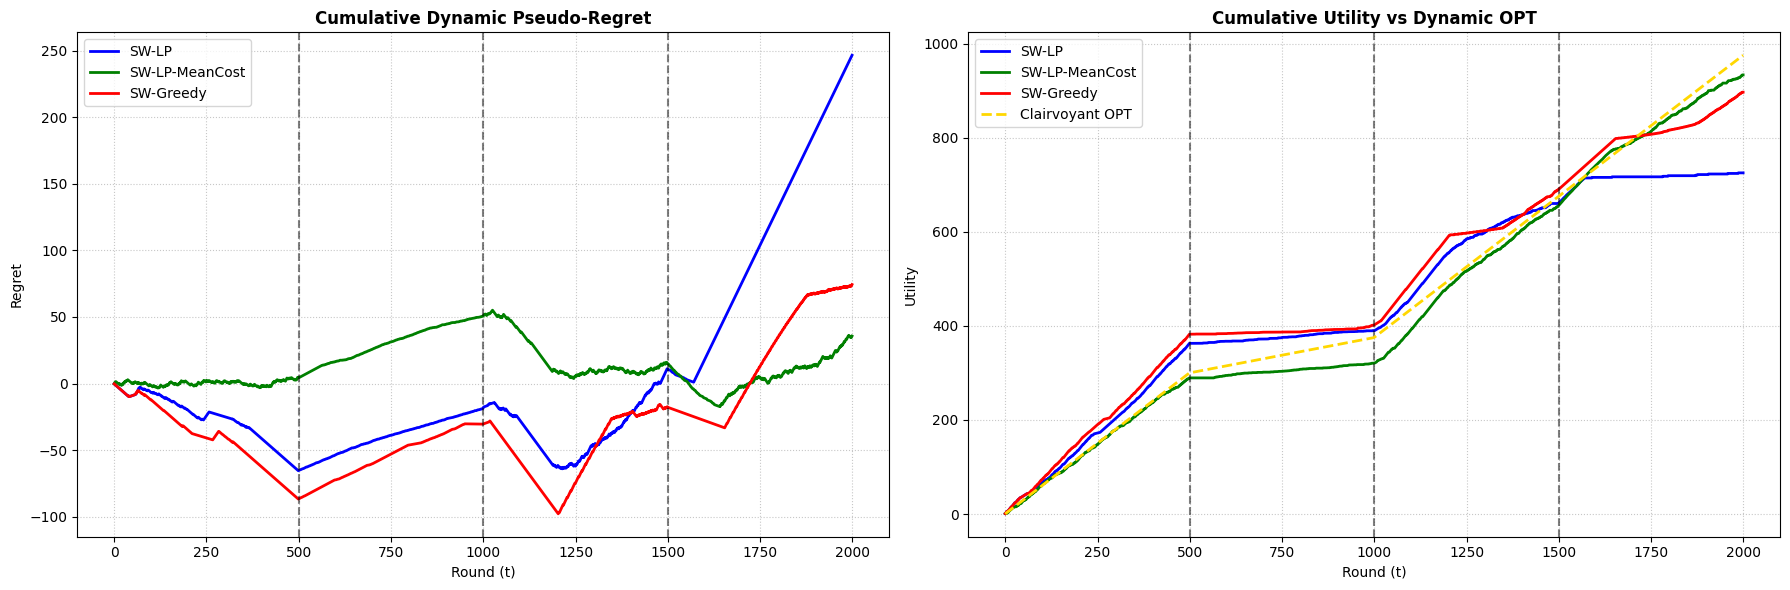

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Enforce deterministic execution
np.random.seed(42)

# 1. Instance Parameters
VALUES = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
B = 0.3 * T
W = 200 
CONFLICT = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]

# 2. Phase Configurations
configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},   # Phase 0
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},   # Phase 1
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},   # Phase 2
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}  # Phase 3
]

# 3. Pre-compute Dynamic Oracles
print("Pre-computing dynamic baselines...")
env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
    VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
)
    
opt_nets = []
for k in range(env_baseline.n_intervals):
    cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
    _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
    opt_nets.append(opt_net)
    print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

# 4. Initialize Safely Scoped Agents
agents = {
    "SW-LP": SW_LP_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "SW-Greedy": SW_Greedy_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W)
}

results = {}

# 5. Execution Loop
for name, agent in agents.items():
    print(f"\nExecuting {name}...")
    
    env = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
    )
    
    regrets, utilities = np.zeros(T), np.zeros(T)
    
    for t in range(T):
        bids = agent.pull_arm()
        won, rew, cost, info = env.resolve_auction(bids)
        agent.update(won, rew, cost)
        
        active_opt_net = opt_nets[info["interval"]]
        regrets[t] = active_opt_net - info["expected_net"]
        utilities[t] = np.sum(rew)

    results[name] = {
        "cum_regret": np.cumsum(regrets),
        "cum_utility": np.cumsum(utilities),
        "final_spend": env.spent,
        "bankrupt": env.bankrupt
    }
    print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | Final Utility: {results[name]['cum_utility'][-1]:.2f} | Bankrupt: {results[name]['bankrupt']}")

# 6. Plot Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {'SW-LP': 'blue', 'SW-LP-MeanCost': 'green', 'SW-Greedy': 'red'}

# Subplot 1: Cumulative Regret
for name, data in results.items():
    axes[0].plot(data['cum_regret'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)
    
axes[0].set_title('Cumulative Dynamic Pseudo-Regret', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Regret')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# Subplot 2: Cumulative Utility
for name, data in results.items():
    axes[1].plot(data['cum_utility'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)
    
opt_util = np.zeros(T)
for k in range(env_baseline.n_intervals):
    opt_util[env_baseline.starts[k]:env_baseline.ends[k]] = opt_nets[k]
axes[1].plot(np.cumsum(opt_util), label='Clairvoyant OPT', color='gold', linestyle='--', lw=2)

axes[1].set_title('Cumulative Utility vs Dynamic OPT', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Utility')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### C-UCB with Change detector : 

In [7]:
import numpy as np
from scipy import optimize

from src.multi_campign_learners import C_UCB_Bidding

# ══════════════════════════════════════════════════════════════════════════════
# CUSUM
# ══════════════════════════════════════════════════════════════════════════════

class CD_C_UCB_Bidding(C_UCB_Bidding):
    """
    Tracks both positive and negative drifts.
    Resets local epoch time to prevent confidence bound explosion.
    """
    def __init__(self, values, bid_space, B, T, conflict_matrix, delta=0.05, lambda_th=1.0):
        super().__init__(values, bid_space, B, T, conflict_matrix)
        self.delta = delta
        self.lambda_th = lambda_th
        self.n_resets = 0
        self._reset_detector()

    def _reset_detector(self):
        """Hard reset of empirical stats, CUSUM trackers, and local epoch."""
        self.avg_f = np.zeros((self.N, self.K))
        self.avg_c = np.zeros((self.N, self.K))
        self.N_pulls = np.zeros((self.N, self.K))
        
        # Local epoch clock to prevent np.log(t) explosion post-reset
        self.t_epoch = 0 

        # Dual Trackers for Two-Sided Detection
        self._ph_mean    = np.zeros((self.N, self.K))
        
        self._ph_pos_sum = np.zeros((self.N, self.K))
        self._ph_pos_min = np.zeros((self.N, self.K))
        
        self._ph_neg_sum = np.zeros((self.N, self.K))
        self._ph_neg_min = np.zeros((self.N, self.K))

    def _ph_update(self, i, k, x):
        """Returns True if a positive or negative drift exceeds lambda_th."""
        n = self.N_pulls[i, k]
        self._ph_mean[i, k] += (x - self._ph_mean[i, k]) / n
        mu = self._ph_mean[i, k]

        # Positive Drift Tracker
        self._ph_pos_sum[i, k] += (x - mu - self.delta)
        self._ph_pos_min[i, k] = min(self._ph_pos_min[i, k], self._ph_pos_sum[i, k])
        pos_alarm = (self._ph_pos_sum[i, k] - self._ph_pos_min[i, k]) > self.lambda_th

        # Negative Drift Tracker
        self._ph_neg_sum[i, k] += (mu - x - self.delta)
        self._ph_neg_min[i, k] = min(self._ph_neg_min[i, k], self._ph_neg_sum[i, k])
        neg_alarm = (self._ph_neg_sum[i, k] - self._ph_neg_min[i, k]) > self.lambda_th

        return pos_alarm or neg_alarm

    def update(self, won_vector, util_vector, cost_vector):
        self.spent += float(np.sum(cost_vector))

        change_detected = False
        for i in range(self.N):
            k = int(self.last_action_indices[i])
            self.N_pulls[i, k] += 1
            n = self.N_pulls[i, k]
            
            x_val = float(util_vector[i])
            self.avg_f[i, k] += (x_val - self.avg_f[i, k]) / n
            self.avg_c[i, k] += (float(cost_vector[i]) - self.avg_c[i, k]) / n

            if self._ph_update(i, k, x_val):
                change_detected = True

        if change_detected:
            self.n_resets += 1
            self._reset_detector()
        else:
            self.t_epoch += 1
            
        self.t += 1

    def _get_bounds(self):
        """Overrides base to utilize t_epoch instead of absolute t."""
        pulled = self.N_pulls > 0
        radius = np.zeros((self.N, self.K))
        
        # Prevent math domain error on log(0)
        safe_t = max(self.t_epoch, 1)
        radius[pulled] = np.sqrt(2.0 * np.log(safe_t + 1) / self.N_pulls[pulled])

        max_net = np.max(self.values[:, None] - self.bid_space[None, :], axis=1)
        f_ucbs  = np.where(pulled, np.minimum(self.avg_f + max_net[:, None] * radius, max_net[:, None]), max_net[:, None])
        c_lcbs  = np.where(pulled, np.maximum(self.avg_c - radius, 1e-8), 1e-8)
        
        f_ucbs[:, 0], c_lcbs[:, 0] = 0.0, 0.0
        return f_ucbs, c_lcbs

# ══════════════════════════════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════════════════════════════

class CD_LP_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa, A_ub=C_sa.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0], bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        gamma = np.clip(res.x, 0.0, 1.0) / np.clip(res.x, 0.0, 1.0).sum() if res.success else np.eye(self.M)[np.argmin(C_sa)]
        self.last_action_indices = self.super_arms[np.random.choice(self.M, p=gamma)]
        return self.bid_space[self.last_action_indices]

class CD_LP_MeanCost_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, _ = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)

        c_hats = np.where(self.N_pulls > 0, self.avg_c, 1e-8)
        c_hats[:, 0] = 0.0
        C_sa_hat = np.sum(c_hats[idx, self.super_arms], axis=1)

        res = optimize.linprog(
            -U_sa, A_ub=C_sa_hat.reshape(1, -1), b_ub=[rem_b / rem_r],
            A_eq=np.ones((1, self.M)), b_eq=[1.0], bounds=[(0.0, 1.0)] * self.M, method='highs-ds'
        )
        gamma = np.clip(res.x, 0.0, 1.0) / np.clip(res.x, 0.0, 1.0).sum() if res.success else np.eye(self.M)[np.argmin(C_sa_hat)]
        self.last_action_indices = self.super_arms[np.random.choice(self.M, p=gamma)]
        return self.bid_space[self.last_action_indices]

class CD_Greedy_Agent(CD_C_UCB_Bidding):
    def pull_arm(self):
        rem_b, rem_r = self.budget - self.spent, max(self.T_horizon - self.t, 1.0)
        if rem_b <= 0 or rem_r <= 0:
            self.last_action_indices = np.zeros(self.N, dtype=int)
            return self.bid_space[self.last_action_indices]

        f_ucbs, c_lcbs = self._get_bounds()
        idx  = np.arange(self.N)
        U_sa = np.sum(f_ucbs[idx, self.super_arms], axis=1)
        C_sa = np.sum(c_lcbs[idx, self.super_arms], axis=1)

        rho        = rem_b / rem_r
        valid_mask = C_sa <= rho
        chosen_idx = np.argmax(np.where(valid_mask, U_sa, -np.inf)) if np.any(valid_mask) else np.argmin(C_sa)
        self.last_action_indices = self.super_arms[chosen_idx]
        return self.bid_space[self.last_action_indices]

Pre-computing dynamic baselines...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1501/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing CD-LP...
Resets Triggered: 11 | Final Regret: 453.07 | Final Utility: 513.30 | Bankrupt: False

Executing CD-LP-MeanCost...
Resets Triggered: 7 | Final Regret: 87.47 | Final Utility: 885.90 | Bankrupt: False

Executing CD-Greedy...
Resets Triggered: 8 | Final Regret: 352.43 | Final Utility: 619.80 | Bankrupt: False


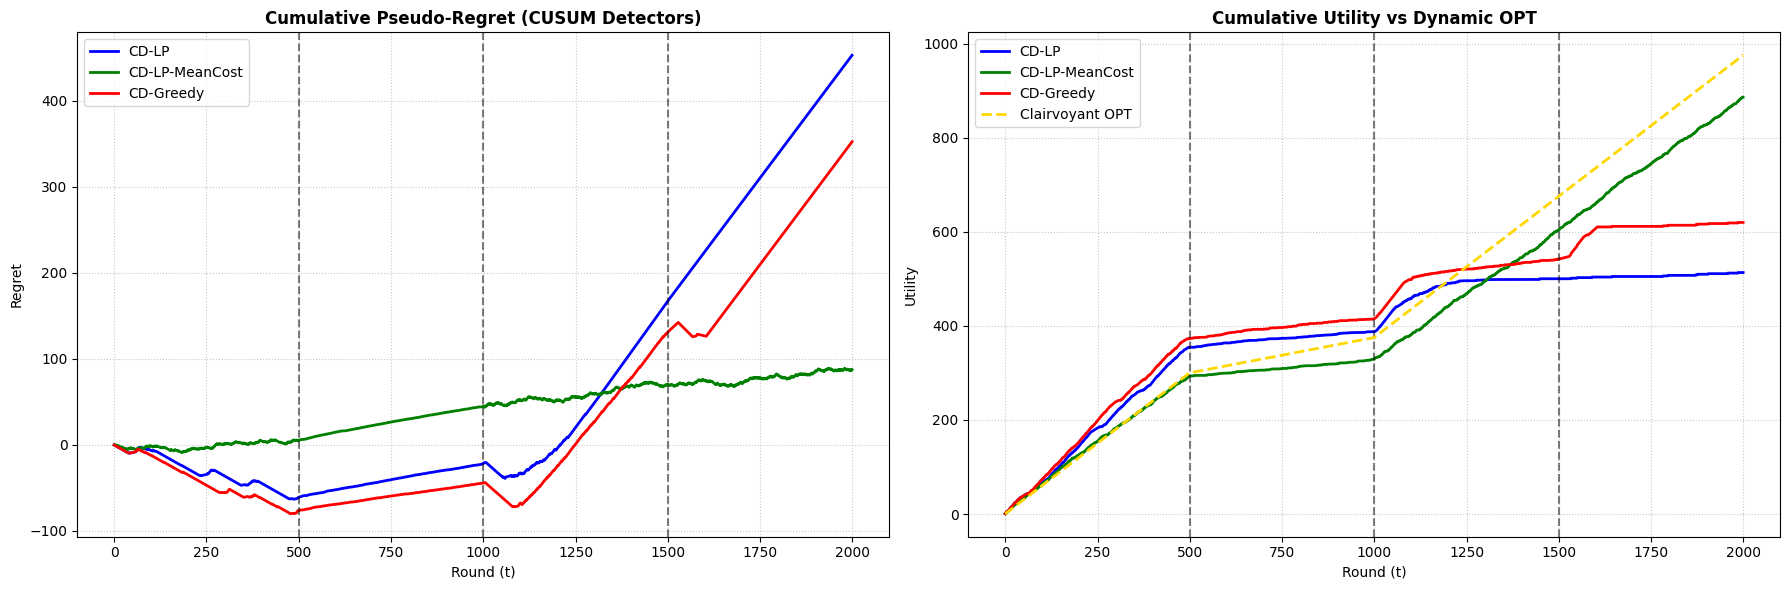

In [8]:
if __name__ == "__main__":
    np.random.seed(42)

    VALUES = [1.5, 1.2]
    BID_SPACE = [0.0, 0.5, 1.0, 1.5]
    T = 2000
    B = 0.3 * T
    CONFLICT = [[False, True], [True, False]]
    BREAKPOINTS = [0, 500, 1000, 1500]

    configs = [
        {"means": [0.4, 0.3], "stds": [0.1, 0.1]},   
        {"means": [1.1, 1.0], "stds": [0.2, 0.2]},   
        {"means": [0.3, 1.2], "stds": [0.1, 0.2]},   
        {"means": [0.2, 0.1], "stds": [0.05, 0.05]}  
    ]

    print("Pre-computing dynamic baselines...")
    env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
    )
        
    opt_nets = []
    for k in range(env_baseline.n_intervals):
        cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
        _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
        opt_nets.append(opt_net)
        print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

    # Initialize CUSUM Agents
    # delta: Minimum drift threshold to accumulate
    # lambda_th: Alarm threshold to trigger full amnesia reset
    DELTA = 0.1
    LAMBDA_TH = 1.5
    
    agents = {
        "CD-LP": CD_LP_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
        "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
        "CD-Greedy": CD_Greedy_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH)
    }

    results = {}

    for name, agent in agents.items():
        print(f"\nExecuting {name}...")
        
        env = SlightlyNonStationaryMultiCampaignEnvironment(
            VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
        )
        
        regrets, utilities = np.zeros(T), np.zeros(T)
        
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            agent.update(won, rew, cost)
            
            active_opt_net = opt_nets[info["interval"]]
            regrets[t] = active_opt_net - info["expected_net"]
            utilities[t] = np.sum(rew)

        results[name] = {
            "cum_regret": np.cumsum(regrets),
            "cum_utility": np.cumsum(utilities),
            "final_spend": env.spent,
            "bankrupt": env.bankrupt,
            "resets": agent.n_resets
        }
        print(f"Resets Triggered: {agent.n_resets} | Final Regret: {results[name]['cum_regret'][-1]:.2f} | Final Utility: {results[name]['cum_utility'][-1]:.2f} | Bankrupt: {results[name]['bankrupt']}")

    # Plot Diagnostics
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    colors = {'CD-LP': 'blue', 'CD-LP-MeanCost': 'green', 'CD-Greedy': 'red'}

    # Subplot 1: Cumulative Regret
    for name, data in results.items():
        axes[0].plot(data['cum_regret'], label=name, color=colors[name], lw=2)
    for bp in BREAKPOINTS[1:]:
        axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)
        
    axes[0].set_title('Cumulative Pseudo-Regret (CUSUM Detectors)', fontweight='bold')
    axes[0].set_xlabel('Round (t)')
    axes[0].set_ylabel('Regret')
    axes[0].legend()
    axes[0].grid(True, linestyle=':', alpha=0.7)

    # Subplot 2: Cumulative Utility
    for name, data in results.items():
        axes[1].plot(data['cum_utility'], label=name, color=colors[name], lw=2)
    for bp in BREAKPOINTS[1:]:
        axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)
        
    opt_util = np.zeros(T)
    for k in range(env_baseline.n_intervals):
        opt_util[env_baseline.starts[k]:env_baseline.ends[k]] = opt_nets[k]
    axes[1].plot(np.cumsum(opt_util), label='Clairvoyant OPT', color='gold', linestyle='--', lw=2)

    axes[1].set_title('Cumulative Utility vs Dynamic OPT', fontweight='bold')
    axes[1].set_xlabel('Round (t)')
    axes[1].set_ylabel('Utility')
    axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

## Primal-dual method

In [18]:
import numpy as np
from src.req3_learners import PrimalDualMultiCampaignAgent, NSPrimalDualMultiCampaignAgent

# Same instance used across SW / CD / Primal-Dual cells for a fair comparison
np.random.seed(42)

VALUES = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
B = 0.3 * T
CONFLICT = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]

configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}
]

print("Pre-computing dynamic baselines...")
env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
    VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
)

opt_nets = []
for k in range(env_baseline.n_intervals):
    cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
    _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
    opt_nets.append(opt_net)
    print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

# Reuse the shared results dict if earlier cells (SW, CD) already created it
if "results" not in globals():
    results = {}

# gamma tuned to THIS environment's interval length (500 rounds), unlike
# Req 3's near-full-horizon tuning: effective memory window = 1/(1-gamma) = 500
GAMMA = 1.0 - 1.0 / 1000

agents = {
    "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
    "NS-Primal-Dual": NSPrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT, gamma=GAMMA),
}

for name, agent in agents.items():
    print(f"\nExecuting {name}...")

    env = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
    )

    # Reset so both agents' Hedge/DiscountedHedge mixture sampling starts
    # from the same point in the RNG stream (see earlier SW fairness note)
    np.random.seed(42)

    regrets, utilities = np.zeros(T), np.zeros(T)

    for t in range(T):
        bids = agent.pull_arm()
        won, rew, cost, info = env.resolve_auction(bids)
        agent.update(won, rew, cost, info["m_t"])  # full feedback

        active_opt_net = opt_nets[info["interval"]]
        regrets[t] = active_opt_net - info["expected_net"]
        utilities[t] = np.sum(rew)

    results[name] = {
        "cum_regret": np.cumsum(regrets),
        "cum_utility": np.cumsum(utilities),
        "final_spend": env.spent,
        "bankrupt": env.bankrupt,
    }
    print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | "
          f"Final Utility: {results[name]['cum_utility'][-1]:.2f} | "
          f"Bankrupt: {results[name]['bankrupt']}")

Pre-computing dynamic baselines...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1501/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing Primal-Dual...
Final Regret: 26.85 | Final Utility: 942.30 | Bankrupt: False

Executing NS-Primal-Dual...
Final Regret: 14.20 | Final Utility: 952.80 | Bankrupt: False


Pre-computing dynamic baselines...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1501/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing Primal-Dual...
Final Regret: 26.85 | Final Utility: 942.30 | Bankrupt: False

Executing NS-Primal-Dual...
Final Regret: 14.20 | Final Utility: 952.80 | Bankrupt: False


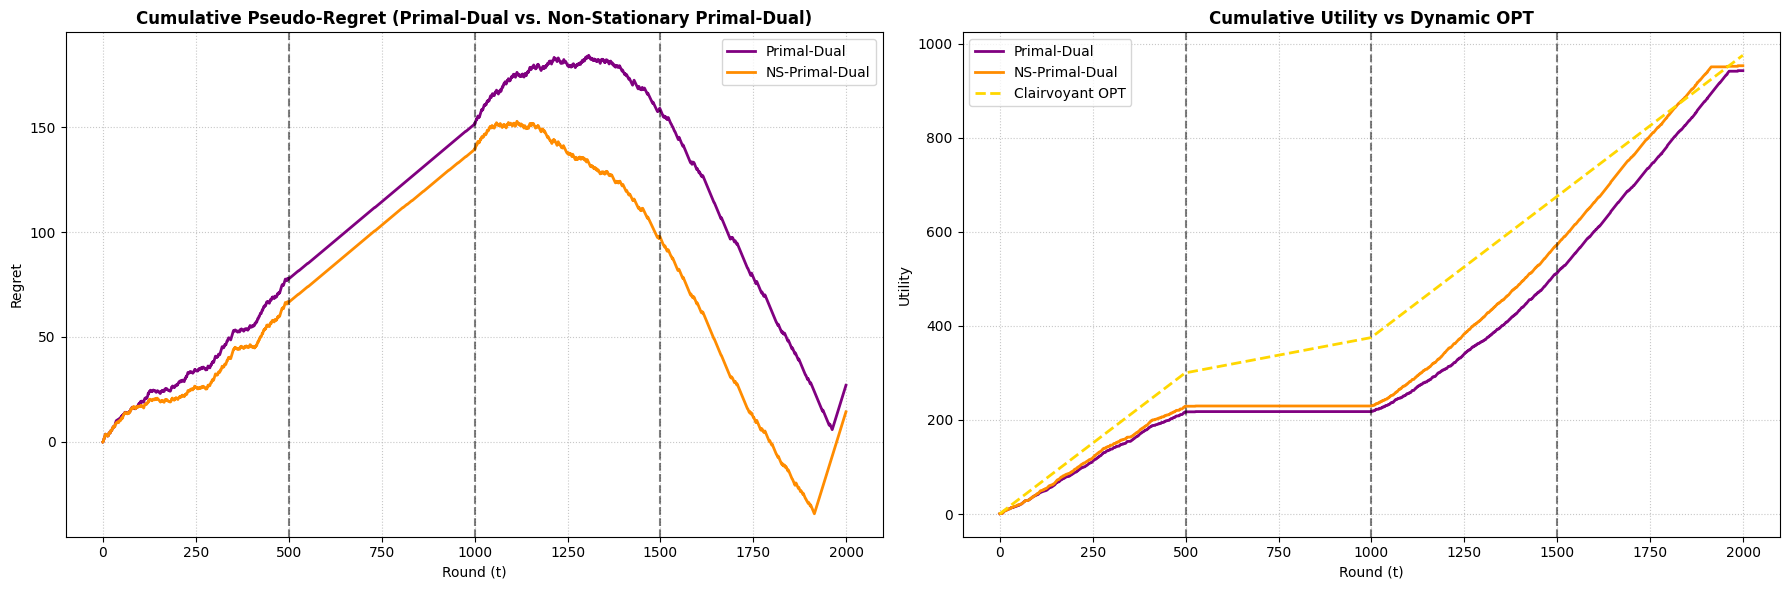

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from src.req3_learners import PrimalDualMultiCampaignAgent, NSPrimalDualMultiCampaignAgent

np.random.seed(42)

VALUES = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
B = 0.3 * T
CONFLICT = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]

configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}
]

print("Pre-computing dynamic baselines...")
env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
    VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
)

opt_nets = []
for k in range(env_baseline.n_intervals):
    cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
    _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
    opt_nets.append(opt_net)
    print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

# gamma tuned to THIS environment's interval length (500 rounds), unlike
# Req 3's near-full-horizon tuning: effective memory window = 1/(1-gamma) = 500
GAMMA = 1.0 - 1.0 / 1000

# Initialize both Primal-Dual variants
agents = {
    "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
    "NS-Primal-Dual": NSPrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT, gamma=GAMMA),
}

results = {}

for name, agent in agents.items():
    print(f"\nExecuting {name}...")

    env = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
    )

    # Reset so both agents' Hedge/DiscountedHedge mixture sampling starts
    # from the same point in the RNG stream
    np.random.seed(42)

    regrets, utilities = np.zeros(T), np.zeros(T)

    for t in range(T):
        bids = agent.pull_arm()
        won, rew, cost, info = env.resolve_auction(bids)

        # Full feedback: both agents' Hedge needs the realized m_t vector
        agent.update(won, rew, cost, info["m_t"])

        active_opt_net = opt_nets[info["interval"]]
        regrets[t] = active_opt_net - info["expected_net"]
        utilities[t] = np.sum(rew)

    results[name] = {
        "cum_regret": np.cumsum(regrets),
        "cum_utility": np.cumsum(utilities),
        "final_spend": env.spent,
        "bankrupt": env.bankrupt,
    }
    print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | "
          f"Final Utility: {results[name]['cum_utility'][-1]:.2f} | "
          f"Bankrupt: {results[name]['bankrupt']}")

# Plot Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {'Primal-Dual': 'purple', 'NS-Primal-Dual': 'darkorange'}

# Subplot 1: Cumulative Regret
for name, data in results.items():
    axes[0].plot(data['cum_regret'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)

axes[0].set_title('Cumulative Pseudo-Regret (Primal-Dual vs. Non-Stationary Primal-Dual)', fontweight='bold')
axes[0].set_xlabel('Round (t)')
axes[0].set_ylabel('Regret')
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# Subplot 2: Cumulative Utility
for name, data in results.items():
    axes[1].plot(data['cum_utility'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)

opt_util = np.zeros(T)
for k in range(env_baseline.n_intervals):
    opt_util[env_baseline.starts[k]:env_baseline.ends[k]] = opt_nets[k]
axes[1].plot(np.cumsum(opt_util), label='Clairvoyant OPT', color='gold', linestyle='--', lw=2)

axes[1].set_title('Cumulative Utility vs Dynamic OPT', fontweight='bold')
axes[1].set_xlabel('Round (t)')
axes[1].set_ylabel('Utility')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Comparison of the performance of the three techniques : 

Pre-computing dynamic baselines...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1501/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing SW-LP-MeanCost...
Final Regret: 56.39 | Final Utility: 911.70 | Bankrupt: False

Executing CD-LP-MeanCost...
Final Regret: 98.92 | Final Utility: 863.10 | Bankrupt: False

Executing Primal-Dual...
Final Regret: 26.85 | Final Utility: 942.30 | Bankrupt: False


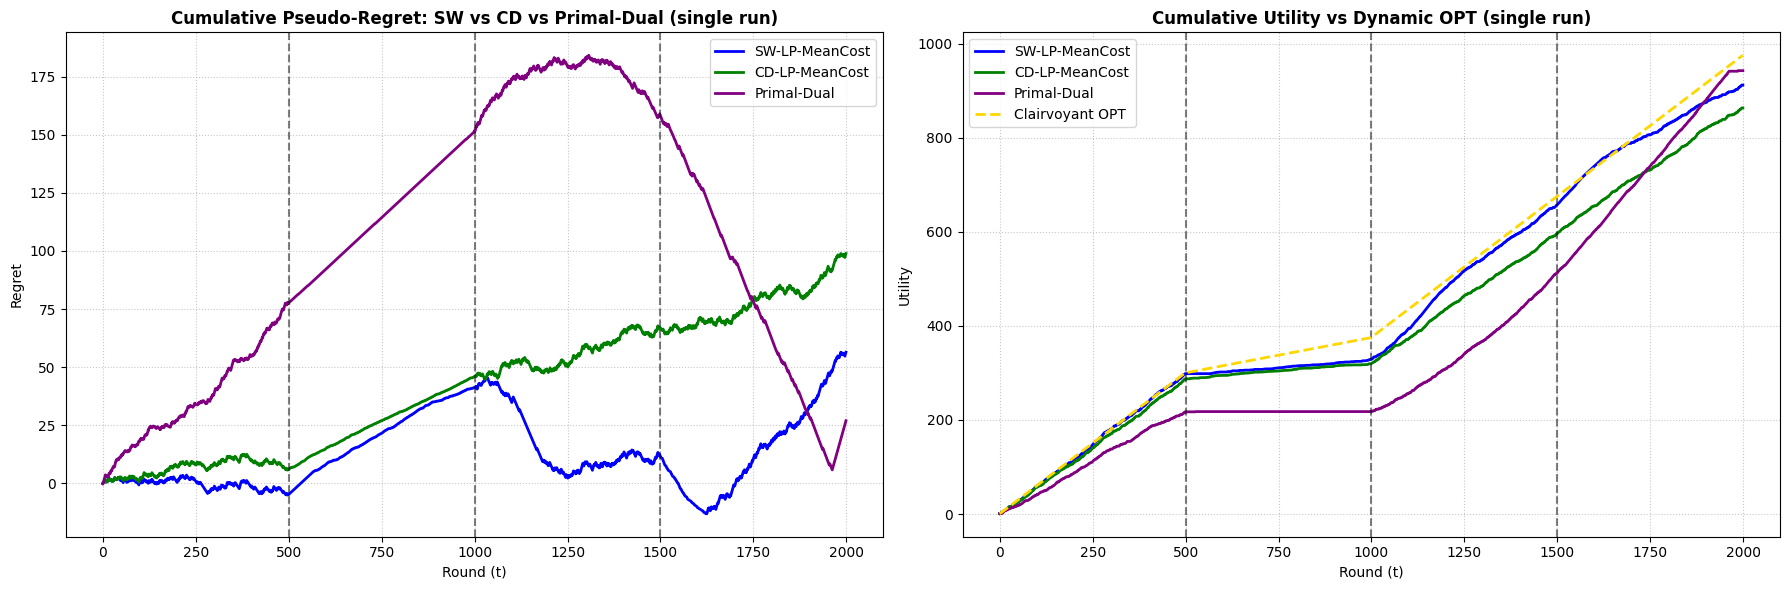

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from src.req3_learners import PrimalDualMultiCampaignAgent

# Assumes SW_LP_MeanCost_Agent, CD_LP_MeanCost_Agent,
# SlightlyNonStationaryMultiCampaignEnvironment, and compute_clairvoyant
# are already defined earlier in this notebook.

np.random.seed(42)

VALUES = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
B = 0.3 * T
CONFLICT = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
W = 200
DELTA, LAMBDA_TH = 0.1, 1.5

configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}
]

print("Pre-computing dynamic baselines...")
env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
    VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
)
opt_nets = []
for k in range(env_baseline.n_intervals):
    cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
    _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
    opt_nets.append(opt_net)
    print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

agents = {
    "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
    "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)

results = {}

for name, agent in agents.items():
    print(f"\nExecuting {name}...")

    env = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
    )
    np.random.seed(42)  # matched RNG start across agents

    regrets, utilities = np.zeros(T), np.zeros(T)

    for t in range(T):
        bids = agent.pull_arm()
        won, rew, cost, info = env.resolve_auction(bids)

        if isinstance(agent, FULL_FEEDBACK_AGENTS):
            agent.update(won, rew, cost, info["m_t"])
        else:
            agent.update(won, rew, cost)

        regrets[t] = opt_nets[info["interval"]] - info["expected_net"]
        utilities[t] = np.sum(rew)

    results[name] = {
        "cum_regret": np.cumsum(regrets),
        "cum_utility": np.cumsum(utilities),
        "bankrupt": env.bankrupt,
    }
    print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | "
          f"Final Utility: {results[name]['cum_utility'][-1]:.2f} | "
          f"Bankrupt: {results[name]['bankrupt']}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}

for name, data in results.items():
    axes[0].plot(data['cum_regret'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Cumulative Pseudo-Regret: SW vs CD vs Primal-Dual (single run)', fontweight='bold')
axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Regret')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

for name, data in results.items():
    axes[1].plot(data['cum_utility'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)
opt_util = np.zeros(T)
for k in range(env_baseline.n_intervals):
    opt_util[env_baseline.starts[k]:env_baseline.ends[k]] = opt_nets[k]
axes[1].plot(np.cumsum(opt_util), label='Clairvoyant OPT', color='gold', linestyle='--', lw=2)
axes[1].set_title('Cumulative Utility vs Dynamic OPT (single run)', fontweight='bold')
axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('Utility')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Completed 10/30 trials
Completed 20/30 trials
Completed 30/30 trials


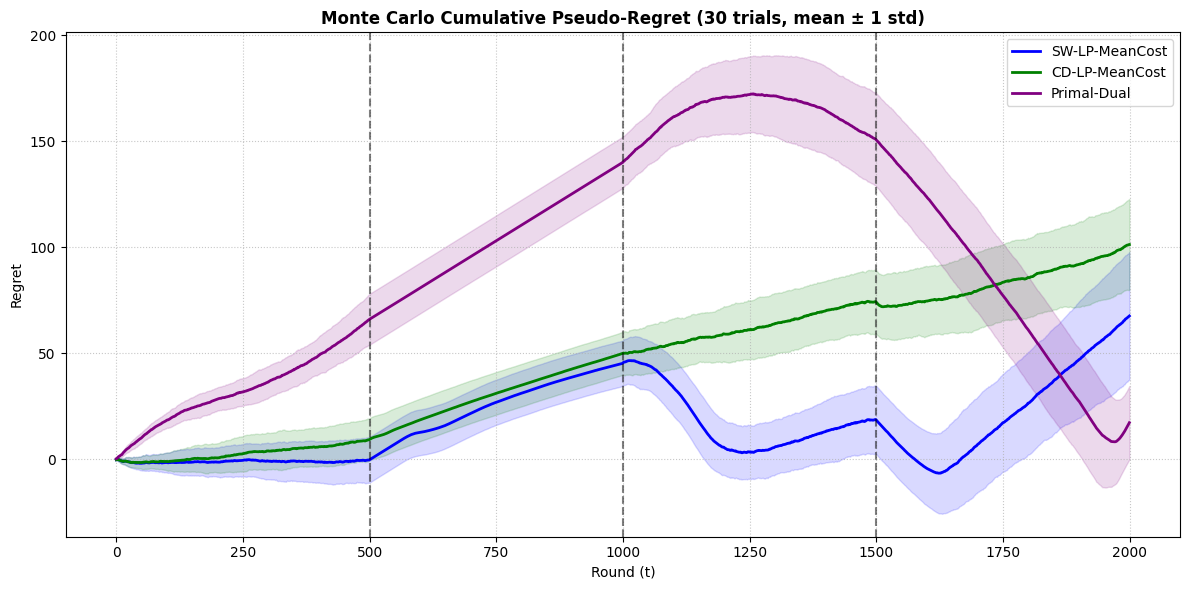


Method              Mean final regret      Std      Min      Max
SW-LP-MeanCost                  67.62    30.13     8.09   166.90
CD-LP-MeanCost                 101.34    21.53    55.91   142.24
Primal-Dual                     17.24    17.32   -15.17    52.79


In [21]:
N_TRIALS = 30  # reduce if this is too slow on your machine

agent_factories = {
    "SW-LP-MeanCost": lambda: SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": lambda: CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
    "Primal-Dual":    lambda: PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}

all_regrets = {name: np.zeros((N_TRIALS, T)) for name in agent_factories}

for trial in range(N_TRIALS):
    for name, factory in agent_factories.items():
        np.random.seed(1000 + trial)  # common random numbers across agents, per trial
        agent = factory()
        env = SlightlyNonStationaryMultiCampaignEnvironment(
            VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian',
            interval_configs=configs, seed=2000 + trial  # varies ACROSS trials
        )

        regrets = np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            regrets[t] = opt_nets[info["interval"]] - info["expected_net"]

        all_regrets[name][trial] = np.cumsum(regrets)

    if (trial + 1) % 10 == 0:
        print(f"Completed {trial + 1}/{N_TRIALS} trials")

fig, ax = plt.subplots(figsize=(12, 6))
for name, regret_matrix in all_regrets.items():
    mean_curve = regret_matrix.mean(axis=0)
    std_curve = regret_matrix.std(axis=0)
    ax.plot(mean_curve, label=name, color=colors[name], lw=2)
    ax.fill_between(np.arange(T), mean_curve - std_curve, mean_curve + std_curve,
                     color=colors[name], alpha=0.15)
for bp in BREAKPOINTS[1:]:
    ax.axvline(bp, color='black', linestyle='--', alpha=0.5)
ax.set_title(f'Monte Carlo Cumulative Pseudo-Regret ({N_TRIALS} trials, mean ± 1 std)', fontweight='bold')
ax.set_xlabel('Round (t)'); ax.set_ylabel('Regret')
ax.legend(); ax.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n{'Method':<18} {'Mean final regret':>18} {'Std':>8} {'Min':>8} {'Max':>8}")
for name, regret_matrix in all_regrets.items():
    finals = regret_matrix[:, -1]
    print(f"{name:<18} {finals.mean():18.2f} {finals.std():8.2f} {finals.min():8.2f} {finals.max():8.2f}")

Pre-computing dynamic baselines (N=4 campaigns)...
Interval 0 (t=0-500): OPT = 0.6000/round
Interval 1 (t=500-1000): OPT = 0.1551/round
Interval 2 (t=1000-1500): OPT = 0.6000/round
Interval 3 (t=1500-2000): OPT = 0.6000/round

Executing SW-LP-MeanCost...
Final Regret: 121.50 | Final Utility: 862.70 | Bankrupt: False

Executing CD-LP-MeanCost...
Final Regret: 136.87 | Final Utility: 849.10 | Bankrupt: False

Executing Primal-Dual...
Final Regret: 357.23 | Final Utility: 625.10 | Bankrupt: True


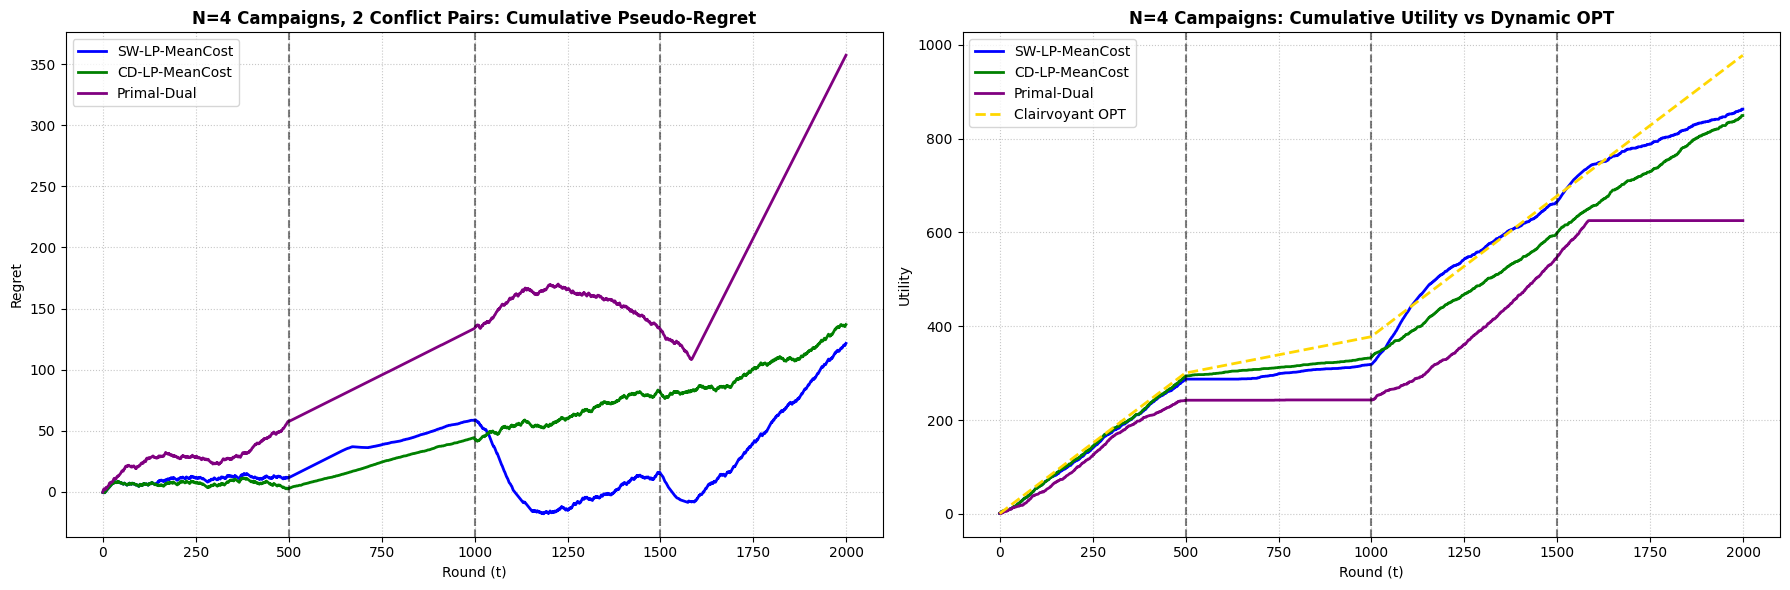

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from src.req3_learners import PrimalDualMultiCampaignAgent

np.random.seed(42)

VALUES    = [1.5, 1.2, 1.0, 0.8]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
B = 0.3 * T
# Two independent conflict pairs: (0,1) compete, (2,3) compete, no cross-pair conflict
CONFLICT = [
    [False, True,  False, False],
    [True,  False, False, False],
    [False, False, False, True ],
    [False, False, True,  False],
]
BREAKPOINTS = [0, 500, 1000, 1500]
W = 200
DELTA, LAMBDA_TH = 0.1, 1.5

configs = [
    {"means": [0.4, 0.3, 0.5, 0.35], "stds": [0.10, 0.10, 0.10, 0.10]},
    {"means": [1.1, 1.0, 0.9, 0.70], "stds": [0.20, 0.20, 0.15, 0.15]},
    {"means": [0.3, 1.2, 0.4, 0.90], "stds": [0.10, 0.20, 0.10, 0.15]},
    {"means": [0.2, 0.1, 0.3, 0.15], "stds": [0.05, 0.05, 0.05, 0.05]},
]

print("Pre-computing dynamic baselines (N=4 campaigns)...")
env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
    VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
)
opt_nets = []
for k in range(env_baseline.n_intervals):
    cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
    _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
    opt_nets.append(opt_net)
    print(f"Interval {k} (t={env_baseline.starts[k]}-{env_baseline.ends[k]}): OPT = {opt_net:.4f}/round")

agents = {
    "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
    "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
    "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
}
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
results = {}

for name, agent in agents.items():
    print(f"\nExecuting {name}...")
    env = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
    )
    np.random.seed(42)

    regrets, utilities = np.zeros(T), np.zeros(T)
    for t in range(T):
        bids = agent.pull_arm()
        won, rew, cost, info = env.resolve_auction(bids)
        if isinstance(agent, FULL_FEEDBACK_AGENTS):
            agent.update(won, rew, cost, info["m_t"])
        else:
            agent.update(won, rew, cost)
        regrets[t] = opt_nets[info["interval"]] - info["expected_net"]
        utilities[t] = np.sum(rew)

    results[name] = {"cum_regret": np.cumsum(regrets), "cum_utility": np.cumsum(utilities), "bankrupt": env.bankrupt}
    print(f"Final Regret: {results[name]['cum_regret'][-1]:.2f} | "
          f"Final Utility: {results[name]['cum_utility'][-1]:.2f} | Bankrupt: {results[name]['bankrupt']}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}

for name, data in results.items():
    axes[0].plot(data['cum_regret'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[0].axvline(bp, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('N=4 Campaigns, 2 Conflict Pairs: Cumulative Pseudo-Regret', fontweight='bold')
axes[0].set_xlabel('Round (t)'); axes[0].set_ylabel('Regret')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

for name, data in results.items():
    axes[1].plot(data['cum_utility'], label=name, color=colors[name], lw=2)
for bp in BREAKPOINTS[1:]:
    axes[1].axvline(bp, color='black', linestyle='--', alpha=0.5)
opt_util = np.zeros(T)
for k in range(env_baseline.n_intervals):
    opt_util[env_baseline.starts[k]:env_baseline.ends[k]] = opt_nets[k]
axes[1].plot(np.cumsum(opt_util), label='Clairvoyant OPT', color='gold', linestyle='--', lw=2)
axes[1].set_title('N=4 Campaigns: Cumulative Utility vs Dynamic OPT', fontweight='bold')
axes[1].set_xlabel('Round (t)'); axes[1].set_ylabel('Utility')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


=== Budget ratio rho = 0.10  (B=200.0) ===
  SW-LP-MeanCost   Final Regret:  -34.54 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:   27.39 | Bankrupt: False
  Primal-Dual      Final Regret:  221.71 | Bankrupt: True

=== Budget ratio rho = 0.20  (B=400.0) ===
  SW-LP-MeanCost   Final Regret:   -4.76 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:   23.63 | Bankrupt: False
  Primal-Dual      Final Regret:  134.72 | Bankrupt: False

=== Budget ratio rho = 0.30  (B=600.0) ===
  SW-LP-MeanCost   Final Regret:   56.39 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:   98.92 | Bankrupt: False
  Primal-Dual      Final Regret:   26.85 | Bankrupt: False

=== Budget ratio rho = 0.50  (B=1000.0) ===
  SW-LP-MeanCost   Final Regret:  220.72 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:  128.91 | Bankrupt: False
  Primal-Dual      Final Regret:  287.73 | Bankrupt: False


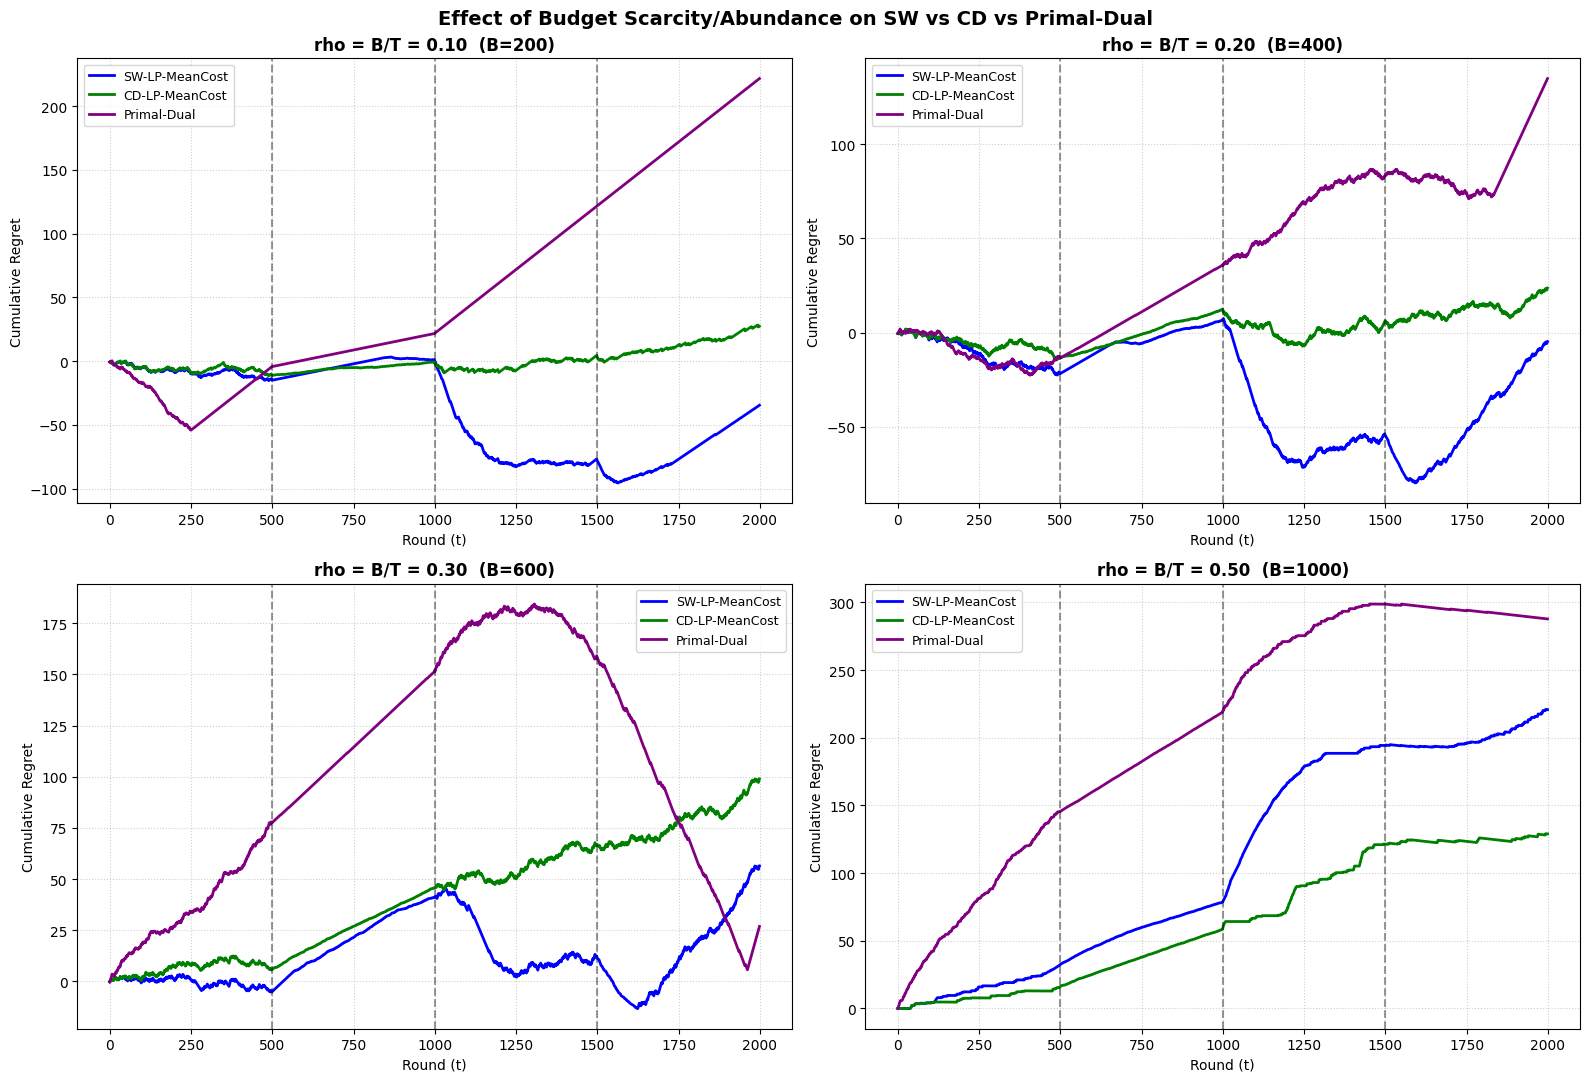

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from src.req3_learners import PrimalDualMultiCampaignAgent

VALUES    = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
T = 2000
CONFLICT = [[False, True], [True, False]]
BREAKPOINTS = [0, 500, 1000, 1500]
W = 200
DELTA, LAMBDA_TH = 0.1, 1.5
configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}
]

BUDGET_RATIOS = [0.10, 0.20, 0.30, 0.50]   # B = ratio * T; 0.30 is your original baseline
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
colors = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax_idx, ratio in enumerate(BUDGET_RATIOS):
    B = ratio * T
    print(f"\n=== Budget ratio rho = {ratio:.2f}  (B={B:.1f}) ===")

    env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
    )
    opt_nets = []
    for k in range(env_baseline.n_intervals):
        cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
        _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
        opt_nets.append(opt_net)

    agents = {
        "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
        "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
        "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
    }

    ax = axes[ax_idx]
    for name, agent in agents.items():
        env = SlightlyNonStationaryMultiCampaignEnvironment(
            VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
        )
        np.random.seed(42)

        regrets = np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            regrets[t] = opt_nets[info["interval"]] - info["expected_net"]

        cum_regret = np.cumsum(regrets)
        ax.plot(cum_regret, label=name, color=colors[name], lw=2)
        print(f"  {name:<16} Final Regret: {cum_regret[-1]:7.2f} | Bankrupt: {env.bankrupt}")

    for bp in BREAKPOINTS[1:]:
        ax.axvline(bp, color='black', linestyle='--', alpha=0.4)
    ax.set_title(f'rho = B/T = {ratio:.2f}  (B={B:.0f})', fontweight='bold')
    ax.set_xlabel('Round (t)'); ax.set_ylabel('Cumulative Regret')
    ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Effect of Budget Scarcity/Abundance on SW vs CD vs Primal-Dual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


=== T = 1000  (B=300.0, breakpoints=[0, 250, 500, 750]) ===
  SW-LP-MeanCost   Final Regret:   32.61 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:   43.12 | Bankrupt: False
  Primal-Dual      Final Regret:   68.80 | Bankrupt: False

=== T = 2000  (B=600.0, breakpoints=[0, 500, 1000, 1500]) ===
  SW-LP-MeanCost   Final Regret:   56.39 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:   98.92 | Bankrupt: False
  Primal-Dual      Final Regret:   26.85 | Bankrupt: False

=== T = 4000  (B=1200.0, breakpoints=[0, 1000, 2000, 3000]) ===
  SW-LP-MeanCost   Final Regret:  113.13 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:  169.15 | Bankrupt: False
  Primal-Dual      Final Regret:   18.16 | Bankrupt: False

=== T = 8000  (B=2400.0, breakpoints=[0, 2000, 4000, 6000]) ===
  SW-LP-MeanCost   Final Regret:   73.14 | Bankrupt: False
  CD-LP-MeanCost   Final Regret:  290.66 | Bankrupt: False
  Primal-Dual      Final Regret:   61.64 | Bankrupt: False


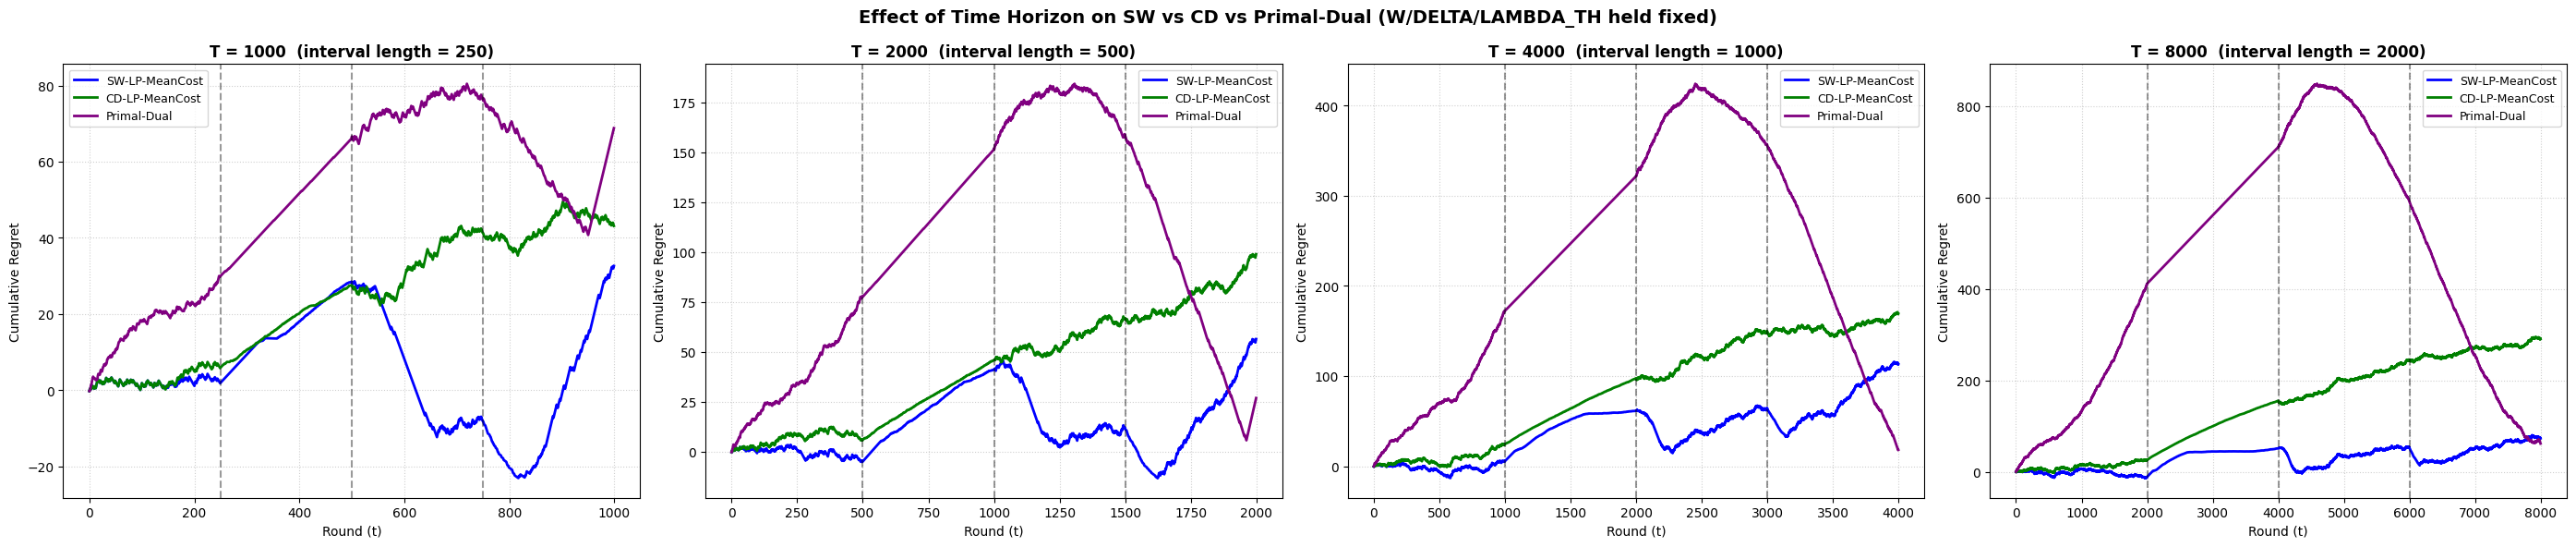

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from src.req3_learners import PrimalDualMultiCampaignAgent

VALUES    = [1.5, 1.2]
BID_SPACE = [0.0, 0.5, 1.0, 1.5]
CONFLICT = [[False, True], [True, False]]
RHO = 0.3   # budget ratio held fixed; B = RHO * T at every horizon

# W, DELTA, LAMBDA_TH are deliberately NOT retuned per T below, so this sweep
# also shows what happens when these fixed hyperparameters (originally tuned
# for interval length 500) become mismatched relative to a shorter/longer interval.
W = 200
DELTA, LAMBDA_TH = 0.1, 1.5

configs = [
    {"means": [0.4, 0.3], "stds": [0.1, 0.1]},
    {"means": [1.1, 1.0], "stds": [0.2, 0.2]},
    {"means": [0.3, 1.2], "stds": [0.1, 0.2]},
    {"means": [0.2, 0.1], "stds": [0.05, 0.05]}
]

T_VALUES = [1000, 2000, 4000, 8000]   # 2000 is your original baseline
FULL_FEEDBACK_AGENTS = (PrimalDualMultiCampaignAgent,)
colors = {'SW-LP-MeanCost': 'blue', 'CD-LP-MeanCost': 'green', 'Primal-Dual': 'purple'}

fig, axes = plt.subplots(1, len(T_VALUES), figsize=(7*len(T_VALUES), 6))

for ax_idx, T in enumerate(T_VALUES):
    B = RHO * T
    BREAKPOINTS = [int(f * T) for f in (0, 0.25, 0.5, 0.75)]   # same 4-phase story, proportional
    print(f"\n=== T = {T}  (B={B:.1f}, breakpoints={BREAKPOINTS}) ===")

    env_baseline = SlightlyNonStationaryMultiCampaignEnvironment(
        VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs
    )
    opt_nets = []
    for k in range(env_baseline.n_intervals):
        cdfs_k = [lambda b, camp_i=i, interval=k: env_baseline.win_prob(interval, camp_i, b) for i in range(env_baseline.N)]
        _, _, opt_net = compute_clairvoyant(VALUES, BID_SPACE, B, T, CONFLICT, cdfs_k)
        opt_nets.append(opt_net)

    agents = {
        "SW-LP-MeanCost": SW_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, W),
        "CD-LP-MeanCost": CD_LP_MeanCost_Agent(VALUES, BID_SPACE, B, T, CONFLICT, delta=DELTA, lambda_th=LAMBDA_TH),
        "Primal-Dual":    PrimalDualMultiCampaignAgent(VALUES, BID_SPACE, B, T, CONFLICT),
    }

    ax = axes[ax_idx]
    for name, agent in agents.items():
        env = SlightlyNonStationaryMultiCampaignEnvironment(
            VALUES, B, T, CONFLICT, BREAKPOINTS, dist_type='gaussian', interval_configs=configs, seed=101
        )
        np.random.seed(42)

        regrets = np.zeros(T)
        for t in range(T):
            bids = agent.pull_arm()
            won, rew, cost, info = env.resolve_auction(bids)
            if isinstance(agent, FULL_FEEDBACK_AGENTS):
                agent.update(won, rew, cost, info["m_t"])
            else:
                agent.update(won, rew, cost)
            regrets[t] = opt_nets[info["interval"]] - info["expected_net"]

        cum_regret = np.cumsum(regrets)
        ax.plot(cum_regret, label=name, color=colors[name], lw=2)
        print(f"  {name:<16} Final Regret: {cum_regret[-1]:7.2f} | Bankrupt: {env.bankrupt}")

    for bp in BREAKPOINTS[1:]:
        ax.axvline(bp, color='black', linestyle='--', alpha=0.4)
    ax.set_title(f'T = {T}  (interval length = {T//4})', fontweight='bold')
    ax.set_xlabel('Round (t)'); ax.set_ylabel('Cumulative Regret')
    ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Effect of Time Horizon on SW vs CD vs Primal-Dual (W/DELTA/LAMBDA_TH held fixed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()